Dataset shape: (300, 10)
Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Profession', 'Work Experience', 'Family Size', 'Purchase Frequency', 'Membership']

Numerical features for clustering:
          Age  Annual Income ($)  Spending Score (1-100)  Work Experience  \
count  300.00             300.00                  300.00           300.00   
mean    37.99           42221.74                   50.35             5.29   
std     13.83           18269.53                   25.50             3.82   
min      7.00           10009.00                    1.00             0.00   
25%     28.00           28501.00                   32.00             2.00   
50%     39.00           42254.00                   51.00             5.00   
75%     46.00           56588.00                   68.25             8.00   
max     95.00           74895.00                  100.00            17.00   

       Family Size  Purchase Frequency  
count       300.00              

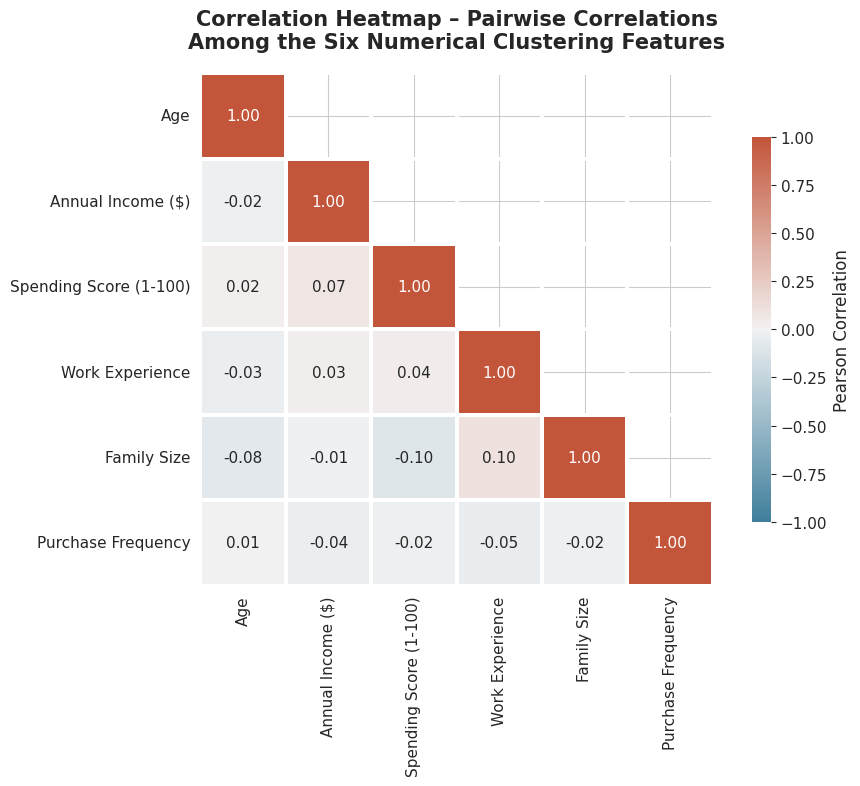

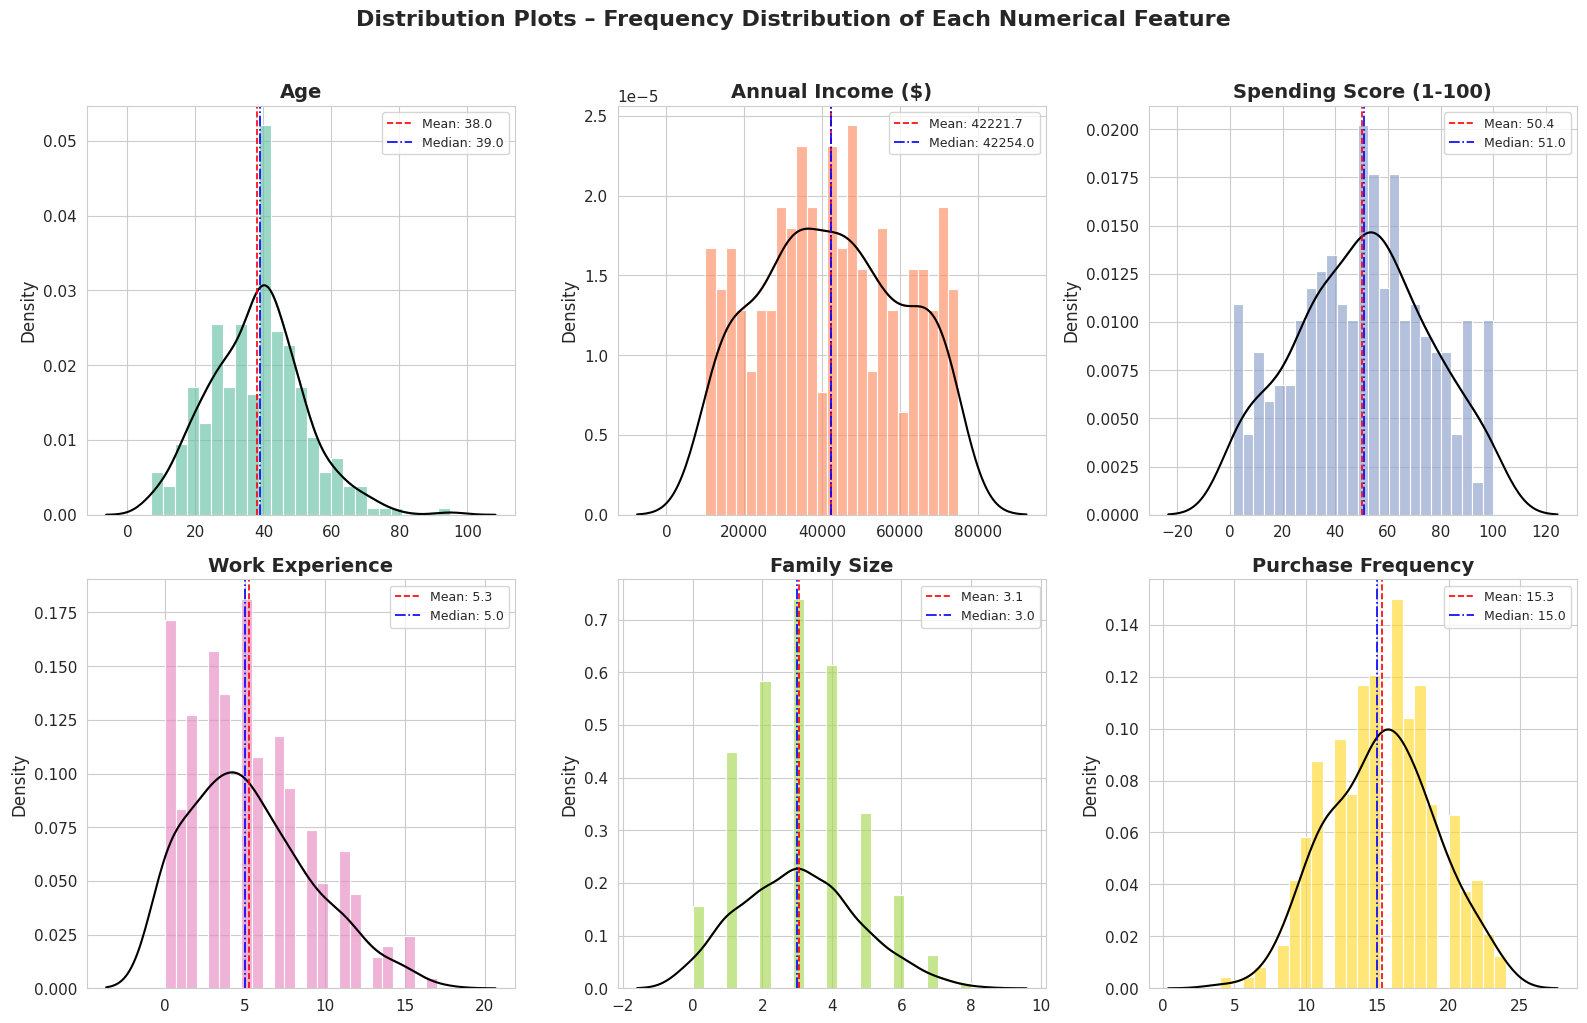


Done!


In [1]:
"""
Generate Correlation Heatmap and Distribution Plots
for the Customer Segmentation Clustering Project.

Features analyzed:
  - Age
  - Annual Income ($)
  - Spending Score (1-100)
  - Work Experience
  - Family Size
  - Purchase Frequency
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Configuration ──────────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
sns.set_style("whitegrid")

GITHUB_RAW_URL = (
    "https://raw.githubusercontent.com/Alfukhan0/"
    "Customer-segmentation-using-Machine-learning/"
    "main/Extended_Mall_Customers_Clean.csv"
)

# ── Load data ──────────────────────────────────────────────────────
df = pd.read_csv(GITHUB_RAW_URL)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")

# Select the six numerical features used for clustering
numeric_cols = [
    "Age",
    "Annual Income ($)",
    "Spending Score (1-100)",
    "Work Experience",
    "Family Size",
    "Purchase Frequency",
]

X = df[numeric_cols].copy()
print("Numerical features for clustering:")
print(X.describe().round(2))
print()

# ╔═════════════════════════════════════════════════════════════════╗
# ║  PLOT 1 – Correlation Heatmap                                  ║
# ╚═════════════════════════════════════════════════════════════════╝
corr = X.corr()

fig1, ax1 = plt.subplots(figsize=(10, 8))

# Use a diverging color map centred at 0
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle mask
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.75, "label": "Pearson Correlation"},
    ax=ax1,
)

ax1.set_title(
    "Correlation Heatmap – Pairwise Correlations\n"
    "Among the Six Numerical Clustering Features",
    fontsize=15,
    fontweight="bold",
    pad=18,
)

plt.tight_layout()
fig1.savefig(
    r"c:\Users\ALFIYA FARIDI\Desktop\final report\correlation_heatmap.png",
    dpi=200,
    bbox_inches="tight",
)
print("[OK] Saved: correlation_heatmap.png")

# ╔═════════════════════════════════════════════════════════════════╗
# ║  PLOT 2 – Distribution Plots (histograms + KDE)                ║
# ╚═════════════════════════════════════════════════════════════════╝
fig2, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

palette = sns.color_palette("Set2", n_colors=len(numeric_cols))

for idx, (col, color) in enumerate(zip(numeric_cols, palette)):
    row, col_idx = divmod(idx, 3)
    ax = axes[row][col_idx]

    sns.histplot(
        X[col],
        kde=True,
        bins=25,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        ax=ax,
        stat="density",
        alpha=0.65,
    )

    # Overlay a separate KDE for emphasis
    sns.kdeplot(X[col], color="black", linewidth=1.5, ax=ax)

    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Density")

    # Add mean and median lines
    mean_val = X[col].mean()
    median_val = X[col].median()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.2, label=f"Mean: {mean_val:.1f}")
    ax.axvline(median_val, color="blue", linestyle="-.", linewidth=1.2, label=f"Median: {median_val:.1f}")
    ax.legend(fontsize=9, loc="upper right")

fig2.suptitle(
    "Distribution Plots – Frequency Distribution of Each Numerical Feature",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
fig2.savefig(
    r"c:\Users\ALFIYA FARIDI\Desktop\final report\distribution_plots.png",
    dpi=200,
    bbox_inches="tight",
)
print("[OK] Saved: distribution_plots.png")

plt.show()
print("\nDone!")
